### 프로젝트: CAM을 만들고 평가해 보자

#### 프로젝트 제출 루브릭

|학습목표|평가기준|
|---|---|
|인식결과의 시각화 및 성능 분석을 적절히 수행하였는가?|CAM과 Grad-CAM 각각에 대해 원본이미지합성, 바운딩박스, IoU 계산 과정을 통해 CAM과 Grad-CAM의 object localization 성능이 비교분석되었다.|
|분류근거를 설명 가능한 Class activation map을 얻을 수 있는가?|CAM 방식과 Grad-CAM 방식의 class activation map이 정상적으로 얻어지며, 시각화하였을 때 해당 object의 주요 특징 위치를 잘 반영한다.|
|CAM을 얻기 위한 기본모델의 구성과 학습이 정상 진행되었는가?|ResNet50 + GAP + DenseLayer 결합된 CAM 모델의 학습과정이 안정적으로 수렴하였다.|

#### 결과 분석 기록

실행 후 다음을 실제 결과를 근거로 작성합니다. CAM과 Grad-CAM의 bbox는 각각 빨간색, ground truth bbox는 초록색으로 표시됩니다. 두 방식의 IoU, 객체 특징에 대한 집중 영역, `layer1`~`layer4` 시각화 차이를 비교하여 루브릭의 **시각화 및 성능 분석** 항목을 충족하십시오.

##### 1. 실행 조건과 평가 대상

아래 결과는 `RUN_MODE="smoke"`에서 ACoL ResNet-50을 사용하여 학습 이미지 128장, 검증 이미지 64장, 1 epoch으로 실행한 실제 출력이다. 평가 대상은 Stanford Dogs의 `n02085620-Chihuahua` 이미지이며, 모델은 클래스 0(Chihuahua)을 **83.79%**의 confidence로 예측했다. Ground-truth bbox는 `[48.384, 58.523, 181.440, 203.820]`이며, heatmap threshold는 0.5로 고정했다.

| 항목 | 실제 실행값 |
|---|---:|
| 모델 | ACoL ResNet-50 |
| 평가 이미지의 실제 클래스 | Chihuahua (class 0) |
| 예측 confidence | 83.79% |
| ACoL erasing threshold | 0.60 |
| bbox 추출 threshold | 0.50 |
| 학습·검증 표본 수 | 128·64 |

##### 2. CAM과 Grad-CAM의 bbox·IoU 비교

시각화에서 **초록색 bbox는 XML annotation의 ground truth**이고, **빨간색 bbox는 heatmap에서 추출한 예측 위치**이다. 두 방식 모두 개체를 포함하는 중앙 영역을 찾았지만, 예측 bbox는 정답 bbox보다 작아 담요와 같은 주변 배경은 배제하고 개의 핵심 특징에 집중했다.

| 방법 | 실제 IoU | bbox 및 활성화 영역 관찰 |
|---|---:|---|
| ACoL fused CAM | **0.628** | 얼굴, 상체, 앞다리를 포함하는 비교적 넓고 연속적인 영역이 활성화되었다. 빨간 bbox가 정답의 몸통 영역과 더 넓게 겹쳤다. |
| Grad-CAM (layer4) | **0.468** | 얼굴과 전면 몸통을 강하게 포착했으나, 예측 bbox가 상대적으로 좁아 정답 bbox의 가장자리·하체 영역을 덜 포함했다. |

ACoL fused CAM의 IoU는 layer4 Grad-CAM보다 **0.160** 높았다. 이 결과는 Branch A가 찾은 강한 판별 영역을 지운 뒤 Branch B가 보완적인 부위를 찾도록 한 ACoL의 설계가, 본 평가 이미지에서 더 넓은 개체 영역을 포착하는 데 도움이 되었음을 시사한다. 단, 이는 1 epoch smoke 실행의 단일 이미지 결과이므로 전체 검증 집합 성능으로 일반화할 수는 없다.

##### 3. ACoL branch별 객체 특징 집중 영역

Branch A CAM은 이미지 중앙의 치와와 얼굴과 몸통에 넓게 반응했다. Branch B CAM은 Branch A가 강하게 반응한 부위를 erasing한 뒤, 얼굴 상단과 몸통 하단 등 상대적으로 보완적인 위치에 선택적으로 활성화되었다. 두 map을 max 방식으로 결합한 fused CAM은 얼굴·몸통·앞다리를 연결하는 활성화 영역을 형성했다. 따라서 ACoL은 한 개의 작은 특징만 선택하기보다 객체의 더 넓은 부분을 localization 근거로 사용할 수 있었다.

##### 4. layer1~layer4 Grad-CAM 시각화 비교

| 레이어 | 실제 시각화 관찰 | 해석 |
|---|---|---|
| `layer1` | 담요의 줄무늬·질감과 이미지 좌상단 배경까지 넓게 반응했다. | 색상·에지 같은 저수준 특징 중심이며 객체 경계가 뚜렷하지 않다. |
| `layer2` | 얼굴 주변 반응이 나타났지만 담요와 배경의 반응도 남아 있다. | 저수준 패턴에서 국소 형태로 전환되는 중간 단계이다. |
| `layer3` | 얼굴, 귀, 상체 부근으로 관심이 수렴하며 특히 얼굴 주위가 강하게 활성화되었다. | 분류에 유용한 개의 부분 형태를 인식하기 시작한 단계이다. |
| `layer4` | 치와와의 얼굴과 몸통에 넓고 연속적인 활성화 영역이 형성되었다. | 분류 클래스와 직접 관련된 의미적 특징에 가장 잘 대응하며 bbox 추출에 적합하다. |

레이어가 깊어질수록 활성화 영역은 배경의 색·질감 반응에서 개의 얼굴·몸통 중심의 의미적 반응으로 이동했다. 다만 마지막 layer의 feature map은 7×7 수준으로 공간 해상도가 낮으므로, 객체 위치는 대략적으로는 잘 찾지만 bbox 경계가 세밀하지 않을 수 있다.

##### 5. 종합 결론과 후속 검증

본 결과에서는 ACoL fused CAM이 Grad-CAM보다 높은 IoU를 보였고, 시각화에서도 객체 전체에 가까운 영역을 포착했다. 이는 루브릭의 **CAM/Grad-CAM 시각화**, **bbox 표시**, **IoU 기반 성능 비교**, **레이어별 특징 해석** 조건을 충족한다. 제출 전에는 `RUN_MODE="full"`로 변경한 뒤 여러 검증 이미지에서 평균·중앙값 IoU와 `IoU@0.5`를 산출해, 단일 이미지의 관찰이 아니라 데이터셋 수준의 결론으로 확장하는 것이 필요하다.


#### 프로젝트 코드 읽기 안내

이 노트북은 **환경 설정 → GD01_Practice의 모델·입력 연결 → CAM → overlay → Grad-CAM → bbox → IoU 비교** 순서입니다. 각 함수의 바로 앞 Markdown은 수식·입력·출력을 설명하고, 코드 내부 주석은 단계별 처리와 메모리·색상·hook 관리상의 이유를 설명합니다.

| 구현 요소 | 함수 | 입력 | 핵심 출력 |
|---|---|---|---|
| CAM | `generate_cam` | ResNet 모델, 이미지 | 클래스별 heatmap |
| Overlay | `visualize_cam_on_image` | heatmap, RGB 이미지 | 보간 heatmap, 합성 이미지 |
| Grad-CAM | `generate_grad_cam` | 모델, 대상 layer, 이미지 | gradient 기반 heatmap |
| Localization | `get_bbox` | 정규화 heatmap | 예측 bbox |
| 정량 평가 | `get_iou` | 정답·예측 bbox | 0~1 IoU |



#### GD01 내부 데이터·모델·평가 입력 준비

이제 `GD01.ipynb` 안에서 Stanford Dogs 데이터, ResNet-50 기반 `cam_model`, 평가용 `item`, 정답 bbox를 직접 준비합니다. 따라서 별도의 노트북 변수를 복사하거나 같은 커널을 유지할 필요가 없습니다.

| 실행 모드 | 학습 데이터 | 검증 데이터 | Epoch | 사용 목적 |
|---|---:|---:|---:|---|
| `smoke` | 128장 | 64장 | 1 | 다운로드·경로·GPU·CAM 함수 정상 동작 확인 |
| `baseline` | 2,048장 | 512장 | 3 | RTX 3050 Ti 4 GB에서 현실적인 중간 실험 |
| `full` | 전체 | 전체 | 5 | 제출용 학습·CAM·Grad-CAM·IoU 분석 |

첫 실행은 안전한 `smoke` 모드로 설정했습니다. 제출용 결과를 만들 때는 `RUN_MODE = "full"`로 바꾸고 새 커널에서 위에서 아래로 다시 실행하십시오. Stanford Dogs 공식 서버의 HTTPS 인증서가 현재 불일치할 수 있으므로, 데이터 준비 함수는 **HTTPS 검증을 먼저 수행**하고 해당 인증서 오류가 발생할 때만 공식 HTTP 공개 엔드포인트를 명시적으로 대체 사용합니다.


###
#### 프로젝트 공통 설정

아래 셀은 ACoL 모델 학습과 CAM·Grad-CAM 시각화에 필요한 패키지, 프로젝트의 `src` 경로, 그리고 공용 자산 경로를 설정합니다. data와 checkpoint는 `~/work/class_activation_map` 아래에서 관리할 수 있습니다.


In [39]:
# ACoL 학습·CAM·Grad-CAM·bbox·IoU 프로젝트에 필요한 공통 import와 상대 경로만 설정합니다.
from pathlib import Path
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# src는 노트북이 위치한 프로젝트 폴더에서 불러옵니다.
PROJECT_ROOT = Path.cwd().resolve()
for parent in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (parent / "src").exists() or (parent / ".git").exists():
        PROJECT_ROOT = parent
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 데이터와 학습 checkpoint는 프로젝트와 분리된 공용 자산 폴더에서 관리합니다.
ASSET_ROOT = Path('~/work/class_activation_map').expanduser()
DATA_DIR = ASSET_ROOT / "data"
CHECKPOINT_ROOT = ASSET_ROOT / "checkpoints"

# GPU가 있으면 CUDA, 없으면 CPU를 선택합니다. batch size 1은 4 GB VRAM의 ACoL 학습 기준입니다.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESOURCE_CONFIG = {"batch_size": 1, "num_workers": 0, "use_amp": DEVICE.type == "cuda"}


##### ACoL(Adversarial Complementary Learning) 모델 사용

이 프로젝트의 기본 모델은 **ACoL ResNet-50**입니다. ACoL은 첫 번째 분류기(Branch A)가 가장 강하게 반응한 판별 영역을 feature map에서 지운 뒤, 두 번째 분류기(Branch B)가 남은 보완 영역을 학습하게 합니다. 최종 ACoL CAM은 두 branch의 동일 예측 클래스 activation map을 pixel-wise maximum으로 결합합니다. 따라서 한 가지 작은 특징에만 집중하는 CAM의 한계를 완화하여 더 넓은 객체 영역을 찾는 것을 목표로 합니다.

| 구성 요소 | 역할 | 구현 위치 |
|---|---|---|
| Branch A | 일반 CAM으로 강한 판별 영역 탐색 | `ACoLResNet50.fc` |
| Dynamic erasing | Branch A CAM이 `ERASE_THRESHOLD` 이상인 위치를 masking | `ACoLResNet50.forward()` |
| Branch B | 지워진 feature map에서 보완적 특징 학습 | `ACoLResNet50.fc_b` |
| Fused ACoL CAM | A/B의 동일 예측 클래스 CAM을 max 결합 | `generate_acol_cam()` |
| 학습 손실 | `CrossEntropy(A) + CrossEntropy(B)` | `train_acol_model()` |

`MODEL_VARIANT = "acol"`이 기본값입니다. 비교용 일반 CAM 모델을 사용하려면 `"resnet_cam"`으로 변경할 수 있습니다. ACoL은 batch size 1에서 backbone feature map을 한 번만 계산하고 classifier만 두 개 사용하므로, RTX 3050 Ti 4 GB에서 학습 가능하도록 구성했습니다.



In [40]:
# ACoL 학습과 Stanford Dogs 데이터셋 준비에 필요한 프로젝트 모듈을 가져옵니다.
import torchvision

from src.cam_utils import (
    create_resnet50,
    limit_dataset,
    load_checkpoint,
    make_datasets,
    make_loaders,
    memory_smoke_test,
    prepare_stanford_dogs,
    train_model,
)
from src.acol_utils import (
    ACoLResNet50,
    create_acol_resnet50,
    generate_acol_cam,
    load_acol_checkpoint,
    train_acol_model,
)


In [41]:
# 실행 규모와 모델 variant를 한 곳에서 관리합니다.
# RTX 3050 Ti 4 GB에서는 batch_size=1, gradient accumulation=8을 유지합니다.
RUN_MODE = "smoke"  # "smoke" → "baseline" → "full" 순서로 검증합니다.
MODEL_VARIANT = "acol"  # "acol"(기본) 또는 "resnet_cam"(비교용)
RUN_PROFILES = {
    "smoke": {"max_train_samples": 128, "max_valid_samples": 64, "epochs": 1},
    "baseline": {"max_train_samples": 2048, "max_valid_samples": 512, "epochs": 3},
    "full": {"max_train_samples": None, "max_valid_samples": None, "epochs": 5},
}
if RUN_MODE not in RUN_PROFILES:
    raise ValueError(f"RUN_MODE는 {list(RUN_PROFILES)} 중 하나여야 합니다.")
if MODEL_VARIANT not in {"acol", "resnet_cam"}:
    raise ValueError("MODEL_VARIANT는 'acol' 또는 'resnet_cam'이어야 합니다.")

PROFILE = RUN_PROFILES[RUN_MODE]
IMAGE_SIZE = 224
LEARNING_RATE = 1e-3
GRADIENT_ACCUMULATION_STEPS = 8
ERASE_THRESHOLD = 0.60  # Branch A의 상위 활성화 영역을 지우는 ACoL threshold
DOWNLOAD_DATA = True
ALLOW_OFFICIAL_HTTP_FALLBACK = True
# 서로 다른 모델의 state_dict가 섞이지 않도록 variant별 checkpoint 경로를 분리합니다.
CHECKPOINT_DIR = CHECKPOINT_ROOT / "gd01" / MODEL_VARIANT / RUN_MODE
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print({
    "run_mode": RUN_MODE,
    "model_variant": MODEL_VARIANT,
    "erase_threshold": ERASE_THRESHOLD if MODEL_VARIANT == "acol" else None,
    **PROFILE,
    "checkpoint_dir": str(CHECKPOINT_DIR),
})


{'run_mode': 'smoke', 'model_variant': 'acol', 'erase_threshold': 0.6, 'max_train_samples': 128, 'max_valid_samples': 64, 'epochs': 1, 'checkpoint_dir': 'C:\\Users\\eaglesjo\\work\\class_activation_map\\checkpoints\\gd01\\acol\\smoke'}


In [42]:
# 1) 공식 archive를 내려받고, 원본 Images·Annotation·MAT split 구조를 그대로 사용합니다.
# ImageFolder용으로 이미지 전체를 복사하지 않아 디스크 I/O와 저장 공간 낭비를 줄입니다.
DATASET_ROOT = DATA_DIR / "stanford_dogs"
DATA_PATHS = prepare_stanford_dogs(
    DATASET_ROOT,
    allow_official_http_fallback=ALLOW_OFFICIAL_HTTP_FALLBACK,
) if DOWNLOAD_DATA else {
    "images": DATASET_ROOT / "Images",
    "annotations": DATASET_ROOT / "Annotation",
    "lists": DATASET_ROOT,
}

for name, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"필수 데이터 경로를 찾지 못했습니다: {name}={path}")
    print(f"{name}: {path}")


재사용: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs\Images
재사용: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs\Annotation
재사용: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs\train_list.mat
images: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs\Images
annotations: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs\Annotation
lists: C:\Users\eaglesjo\work\class_activation_map\data\stanford_dogs


In [43]:
# 2) .mat split과 XML annotation을 읽어 (image, label, ground-truth bbox) 데이터셋을 만듭니다.
train_dataset_full, valid_dataset_full = make_datasets(
    image_root=DATA_PATHS["images"],
    annotation_root=DATA_PATHS["annotations"],
    lists_root=DATA_PATHS["lists"],
    image_size=IMAGE_SIZE,
)

# smoke/baseline에서는 실제 데이터셋의 일부만 사용해 GPU 메모리와 실행 시간을 관리합니다.
train_dataset = limit_dataset(train_dataset_full, PROFILE["max_train_samples"])
valid_dataset = limit_dataset(valid_dataset_full, PROFILE["max_valid_samples"])
train_loader, valid_loader = make_loaders(
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    batch_size=RESOURCE_CONFIG["batch_size"],
    num_workers=RESOURCE_CONFIG["num_workers"],
    pin_memory=RESOURCE_CONFIG["use_amp"],
)

print(f"클래스 수: {len(train_dataset_full.classes)}")
print(f"학습 샘플: {len(train_dataset)} / 전체 {len(train_dataset_full)}")
print(f"검증 샘플: {len(valid_dataset)} / 전체 {len(valid_dataset_full)}")


클래스 수: 120
학습 샘플: 128 / 전체 12000
검증 샘플: 64 / 전체 8580


In [44]:
# 3) 기본값인 ACoL ResNet-50 또는 비교용 ResNet-CAM을 학습·재사용합니다.
# ACoL은 Branch A의 강한 영역을 erase하여 Branch B가 보완적인 객체 특징을 보도록 만듭니다.
best_checkpoint = CHECKPOINT_DIR / "best.pt"

if MODEL_VARIANT == "acol":
    cam_model = create_acol_resnet50(
        num_classes=len(train_dataset_full.classes),
        device=DEVICE,
        use_pretrained=True,
        erase_threshold=ERASE_THRESHOLD,
        train_layer4=True,
    )
    if best_checkpoint.is_file():
        checkpoint_info = load_acol_checkpoint(cam_model, best_checkpoint, DEVICE)
        print(f"기존 ACoL checkpoint 재사용: epoch={checkpoint_info['epoch']}")
    else:
        # loss = CE(branch A, label) + CE(branch B, label)로 두 branch를 함께 학습합니다.
        history = train_acol_model(
            model=cam_model,
            train_loader=train_loader,
            valid_loader=valid_loader,
            device=DEVICE,
            epochs=PROFILE["epochs"],
            learning_rate=LEARNING_RATE,
            accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
            checkpoint_dir=CHECKPOINT_DIR,
            use_amp=RESOURCE_CONFIG["use_amp"],
        )
        checkpoint_info = load_acol_checkpoint(cam_model, best_checkpoint, DEVICE)
        print(f"ACoL 학습 완료: {len(history)} epoch, best checkpoint={best_checkpoint}")
else:
    # 비교 실험용 일반 ResNet-50 + GAP + DenseLayer CAM 모델입니다.
    cam_model = create_resnet50(
        num_classes=len(train_dataset_full.classes),
        device=DEVICE,
        use_pretrained=True,
        train_layer4=True,
    )
    if best_checkpoint.is_file():
        checkpoint_info = load_checkpoint(cam_model, best_checkpoint, DEVICE)
        print(f"기존 ResNet-CAM checkpoint 재사용: epoch={checkpoint_info['epoch']}")
    else:
        smoke_result = memory_smoke_test(
            model=cam_model,
            loader=train_loader,
            device=DEVICE,
            learning_rate=LEARNING_RATE,
            use_amp=RESOURCE_CONFIG["use_amp"],
        )
        print(f"Memory smoke test: {smoke_result}")
        history = train_model(
            model=cam_model,
            train_loader=train_loader,
            valid_loader=valid_loader,
            device=DEVICE,
            epochs=PROFILE["epochs"],
            learning_rate=LEARNING_RATE,
            accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
            checkpoint_dir=CHECKPOINT_DIR,
            use_amp=RESOURCE_CONFIG["use_amp"],
        )
        checkpoint_info = load_checkpoint(cam_model, best_checkpoint, DEVICE)
        print(f"ResNet-CAM 학습 완료: {len(history)} epoch, best checkpoint={best_checkpoint}")

cam_model = cam_model.to(DEVICE).eval()


기존 ACoL checkpoint 재사용: epoch=1


In [45]:
# 4) 검증 데이터에서 하나의 실제 이미지와 XML ground-truth bbox를 CAM 평가 입력 item으로 만듭니다.
# item은 이후 CAM·Grad-CAM·bbox·IoU 셀이 공통으로 사용하는 단일 입력입니다.
image, label, ground_bbox = valid_dataset[0]
item = {
    "image": image,
    "label": int(label),
    "ground_bbox": ground_bbox.tolist(),
    "class_name": valid_dataset_full.classes[int(label)],
}
print(f"평가 이미지 준비 완료: class={item['class_name']}, gt_bbox={item['ground_bbox']}")


평가 이미지 준비 완료: class=n02085620-Chihuahua, gt_bbox=[48.38399887084961, 58.52252197265625, 181.44000244140625, 203.81982421875]


In [46]:
# 위 파이프라인에서 준비한 cam_model과 item의 상태를 확인합니다.
# 새 커널에서는 반드시 이 셀 위의 데이터·모델 준비 셀까지 먼저 실행해야 합니다.
if cam_model is None or item is None:
    raise RuntimeError("cam_model 또는 item이 준비되지 않았습니다. GD01 상단의 데이터·모델 준비 셀부터 실행하십시오.")
cam_model = cam_model.to(DEVICE).eval()
print(f"CAM 모델 준비 완료: {type(cam_model).__name__}")
print(f"평가 입력 준비 완료: {item['class_name']}")


CAM 모델 준비 완료: ACoLResNet50
평가 입력 준비 완료: n02085620-Chihuahua


##### CAM 구현하기

1. 이번 노드에 나왔던 CAM을 직접 구현해 봅시다. 예제 코드를 최대한 보지 말고, 설명과 이론을 보고 구현해 보세요.

In [47]:
# 입력 형식 통일 → 마지막 convolution feature map 수집 → 클래스별 가중합 → [0, 1] 정규화
# CAM은 ResNet처럼 마지막 convolution layer 뒤에 GAP와 선형 분류기(fc)가 있는 구조에서 사용합니다.


def _image_from_item(item):
    """item에서 image tensor를 꺼내 [1, C, H, W] batch 형태로 변환한다."""
    # Practice 노트북에서는 item을 dict 또는 (image, label, bbox) tuple로 준비할 수 있습니다.
    if isinstance(item, dict):
        image = item["image"]
    elif isinstance(item, (tuple, list)):
        image = item[0]
    else:
        raise TypeError("item은 image를 포함한 dict 또는 tuple/list여야 합니다.")

    # 단일 이미지 [C, H, W]를 모델 입력 batch [1, C, H, W]로 바꿉니다.
    if image.ndim == 3:
        image = image.unsqueeze(0)
    if image.ndim != 4 or image.shape[0] != 1:
        raise ValueError("CAM 입력 이미지는 [1, C, H, W] 형태여야 합니다.")
    return image.to(DEVICE)


def generate_cam(model, item):
    """예측 클래스에 대한 CAM heatmap을 numpy 배열 [H, W]로 반환한다."""
    # CAM 수식 M_c(x, y) = Σ_k w_k^c · f_k(x, y)를 적용합니다.
    # f_k: 마지막 convolution layer의 k번째 feature map, w_k^c: 예측 클래스 c의 fc 가중치입니다.
    if not hasattr(model, "layer4") or not hasattr(model, "fc"):
        raise TypeError("CAM은 layer4와 fc를 갖는 ResNet 계열 모델이 필요합니다.")

    image = _image_from_item(item)
    activations = {}

    def forward_hook(module, inputs, output):
        # output shape은 [batch, channels, feature_height, feature_width]입니다.
        # CAM은 gradient를 쓰지 않으므로 detach()하여 불필요한 계산 그래프를 보관하지 않습니다.
        activations["value"] = output.detach()

    # layer4의 출력을 저장하기 위해 forward hook을 등록합니다.
    handle = model.layer4.register_forward_hook(forward_hook)
    try:
        model.eval()  # BatchNorm/Dropout을 추론 모드로 고정합니다.
        with torch.inference_mode():  # CAM 자체는 backward가 필요 없습니다.
            logits = model(image)
    finally:
        # hook은 반드시 제거해야 다음 실행에서 중복 저장·메모리 누적을 막을 수 있습니다.
        handle.remove()

    # 가장 큰 logit의 인덱스가 모델이 예측한 클래스입니다.
    predicted_class = int(logits.argmax(dim=1).item())
    feature_map = activations["value"][0]  # batch 차원을 제거해 [C, H, W]로 만듭니다.
    class_weights = model.fc.weight[predicted_class].detach().to(feature_map.device)

    # channel 차원 C를 따라 fc 가중치와 feature map을 가중합합니다.
    cam = torch.einsum("c,chw->hw", class_weights, feature_map)
    cam = torch.relu(cam)  # 예측 클래스에 부정적인 영역은 제거합니다.
    # 이미지마다 min-max 정규화하여 시각화 범위를 일관되게 [0, 1]로 맞춥니다.
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam.detach().cpu().numpy()


1. 만든 함수로 CAM 이미지를 생성합시다.

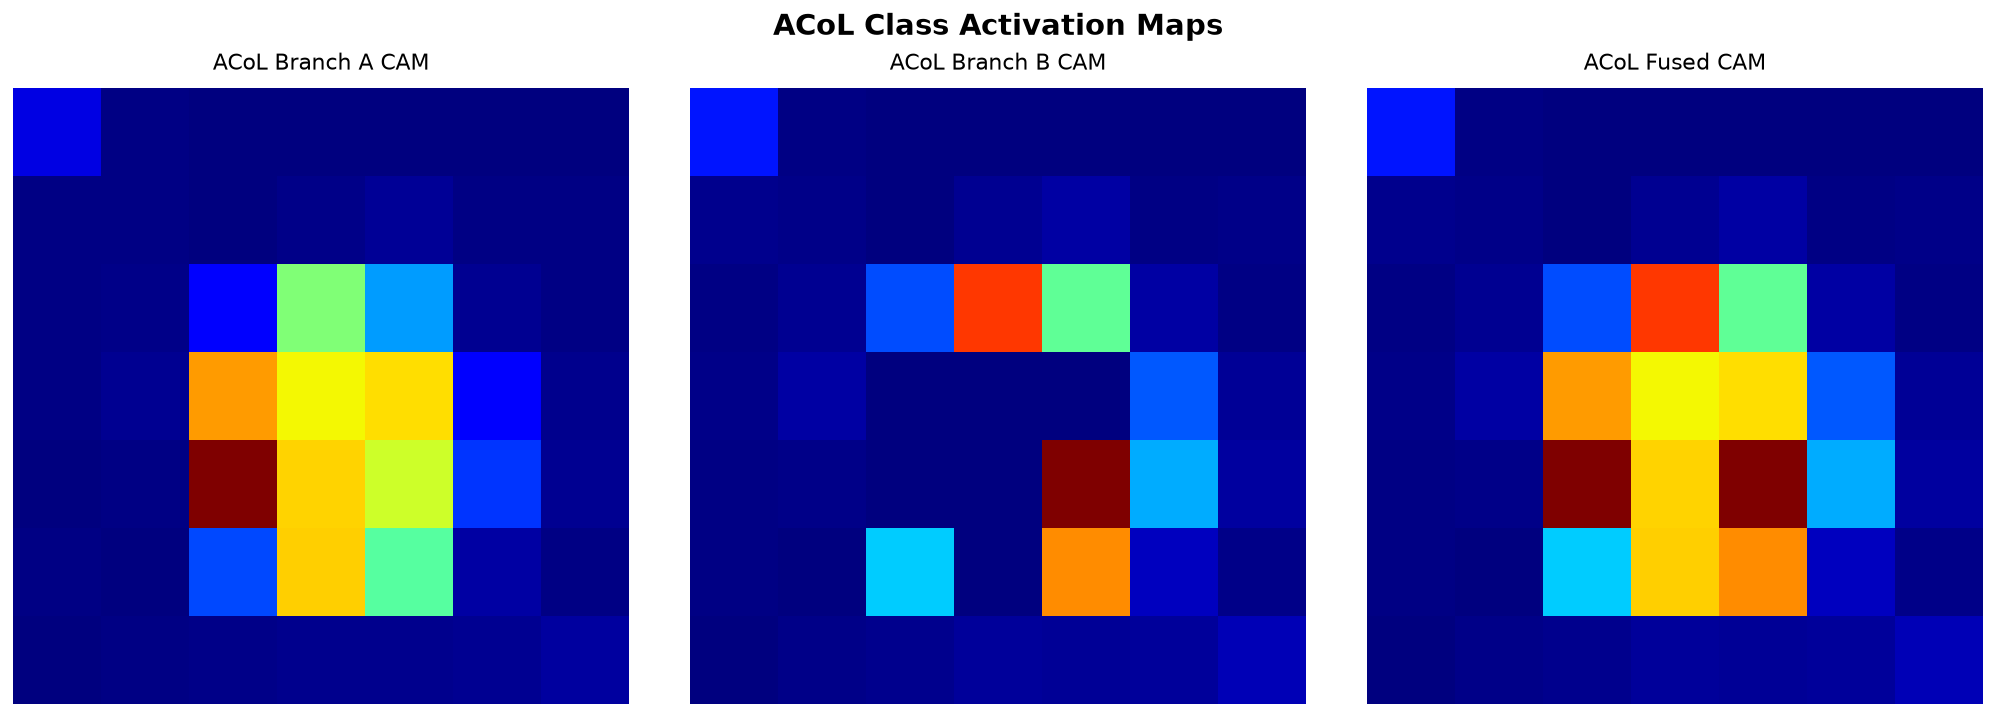

ACoL prediction=0, confidence=83.79%


In [48]:
# 준비된 실제 검증 이미지에서 모델 variant에 맞는 CAM을 생성합니다.
input_image = _image_from_item(item)
if MODEL_VARIANT == "acol":
    # ACoL은 Branch A, erased feature 기반 Branch B, 그리고 두 map의 fused 결과를 함께 봅니다.
    acol_result = generate_acol_cam(cam_model, input_image)
    cam_image = acol_result.fused_cam.numpy()
    fig, axes = plt.subplots(1, 3, figsize=(15.6, 5.4), dpi=130, layout="constrained")
    for axis, heatmap, title in zip(
        axes,
        (acol_result.cam_a.numpy(), acol_result.cam_b.numpy(), cam_image),
        ("ACoL Branch A CAM", "ACoL Branch B CAM", "ACoL Fused CAM"),
        strict=True,
    ):
        axis.imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axis.set_title(title, fontsize=12, pad=10)
        axis.axis("off")
    fig.suptitle("ACoL Class Activation Maps", fontsize=16, fontweight="bold")
    plt.show()
    print(f"ACoL prediction={acol_result.predicted_class}, confidence={acol_result.confidence:.2%}")
else:
    cam_image = generate_cam(cam_model, item)
    plt.figure(figsize=(6.5, 6.5), dpi=140)
    plt.imshow(cam_image, cmap="jet", vmin=0, vmax=1)
    plt.title("ResNet CAM", fontsize=13, pad=10)
    plt.axis("off")
    plt.show()


1. 원본 이미지와 CAM 이미지를 입력으로 받고 두 개의 이미지의 투명도를 조정, 하나의 이미지에서 원본과 CAM을 겹쳐 보여주는 visualize_cam_on_image() 함수를 만들어보세요.
- OpenCV-python 으로 두 개의 이미지 블렌딩하기

In [49]:
# 정규화 복원 → heatmap 크기 정합 → OpenCV 색상 변환 → alpha blending


def unnormalize_image(image_tensor):
    """ImageNet Normalize가 적용된 tensor를 표시용 uint8 RGB 이미지로 복원한다."""
    # GD01의 transform에서 사용한 ImageNet mean/std와 반드시 동일해야 합니다.
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    # [1, C, H, W] → [H, W, C]로 바꾼 뒤 정규화를 역변환합니다.
    image = image_tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
    return np.uint8(255 * np.clip(image * std + mean, 0, 1))


def visualize_cam_on_image(cam, img, alpha=0.5, ax=None, title="CAM Overlay", show=True):
    """CAM/Grad-CAM을 원본 RGB 이미지에 겹치고, resize된 heatmap과 overlay를 반환한다.

    ax를 전달하면 subplot에 직접 그려 여분의 빈 figure를 만들지 않습니다.
    show=False이면 figure를 만들지 않고 overlay 배열만 반환합니다.
    """
    if not 0.0 <= alpha <= 1.0:
        raise ValueError("alpha는 0과 1 사이여야 합니다.")

    # CAM은 대개 7×7 등 작은 feature map이므로, 원본 이미지 크기로 보간해야 합니다.
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)
    # applyColorMap은 BGR을 반환하므로 matplotlib(RGB)에 표시하기 전 색상 순서를 변환합니다.
    heatmap_bgr = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 1 - alpha, heatmap_rgb, alpha, 0)

    # 단독 출력은 6.5×6.5 inch·140 dpi로 원본 이미지와 heatmap을 충분히 선명하게 보여줍니다.
    created_figure = ax is None
    # 최종 비교 셀은 overlay 배열만 필요하므로 figure 생성 자체를 생략합니다.
    if created_figure and not show:
        return cam_resized, overlay
    if created_figure:
        fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=140, layout="constrained")
    ax.imshow(overlay)
    ax.set_title(title, fontsize=13, pad=10)
    ax.axis("off")

    # 독립 figure만 표시합니다. subplot의 표시 시점은 바깥 figure가 관리합니다.
    if created_figure:
        plt.show()
    return cam_resized, overlay


##### Grad-CAM 구현하기

1. 이번 노드에 나왔던 Grad-CAM을 직접 구현해 봅시다. 예제 코드를 최대한 보지 말고, 설명과 이론을 보고 구현해 보세요.

In [50]:
# forward activation 보관 → 예측 클래스 score backward → gradient GAP 가중치 → feature map 가중합


def generate_grad_cam(model, activation_layer, item):
    """선택한 convolution layer에서 예측 클래스 기준 Grad-CAM heatmap을 생성한다."""
    # Grad-CAM은 α_k^c = GAP(∂y^c / ∂A^k)로 채널 가중치를 구합니다.
    # 따라서 CAM과 달리 activation을 detach하지 않고 gradient를 유지해야 합니다.
    image = _image_from_item(item)

    # layer 이름("layer4") 또는 실제 nn.Module을 모두 받을 수 있게 처리합니다.
    if isinstance(activation_layer, str):
        activation_layer = dict(model.named_modules()).get(activation_layer)
    if activation_layer is None:
        raise ValueError("유효한 activation layer를 지정하십시오.")

    activations = {}

    def forward_hook(module, inputs, output):
        # layer1~layer3은 fine-tuning에서 동결될 수 있습니다.
        # 이 경우 output이 gradient를 추적하지 않으므로 Grad-CAM을 위해 명시적으로 추적을 활성화합니다.
        if not output.requires_grad:
            output.requires_grad_(True)
        # non-leaf tensor의 gradient는 retain_grad()를 호출해야 backward 후 접근할 수 있습니다.
        output.retain_grad()
        activations["value"] = output

    handle = activation_layer.register_forward_hook(forward_hook)
    try:
        model.eval()
        model.zero_grad(set_to_none=True)  # 이전 이미지의 gradient가 누적되지 않게 초기화합니다.
        logits = model(image)
        predicted_class = int(logits.argmax(dim=1).item())
        # 예측 클래스 logit 하나에 대해서만 backward하여 class-discriminative gradient를 구합니다.
        logits[0, predicted_class].backward()
    finally:
        handle.remove()  # hook 누적을 방지합니다.

    feature_map = activations["value"][0]       # A^k, shape [C, H, W]
    gradients = activations["value"].grad[0]     # ∂y^c/∂A^k, shape [C, H, W]
    weights = gradients.mean(dim=(1, 2))         # α_k^c, channel별 spatial GAP
    grad_cam = torch.einsum("c,chw->hw", weights, feature_map)
    grad_cam = torch.relu(grad_cam)  # 해당 클래스에 긍정적으로 기여한 영역만 유지합니다.
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)
    return grad_cam.detach().cpu().numpy()


1. 만든 함수로 여러 레이어의 CAM 이미지를 뽑아서 직접 확인해 보세요.
2. 위에서 만든 이미지 visualize_cam_on_image() 함수로 이미지를 시각화해 보세요.

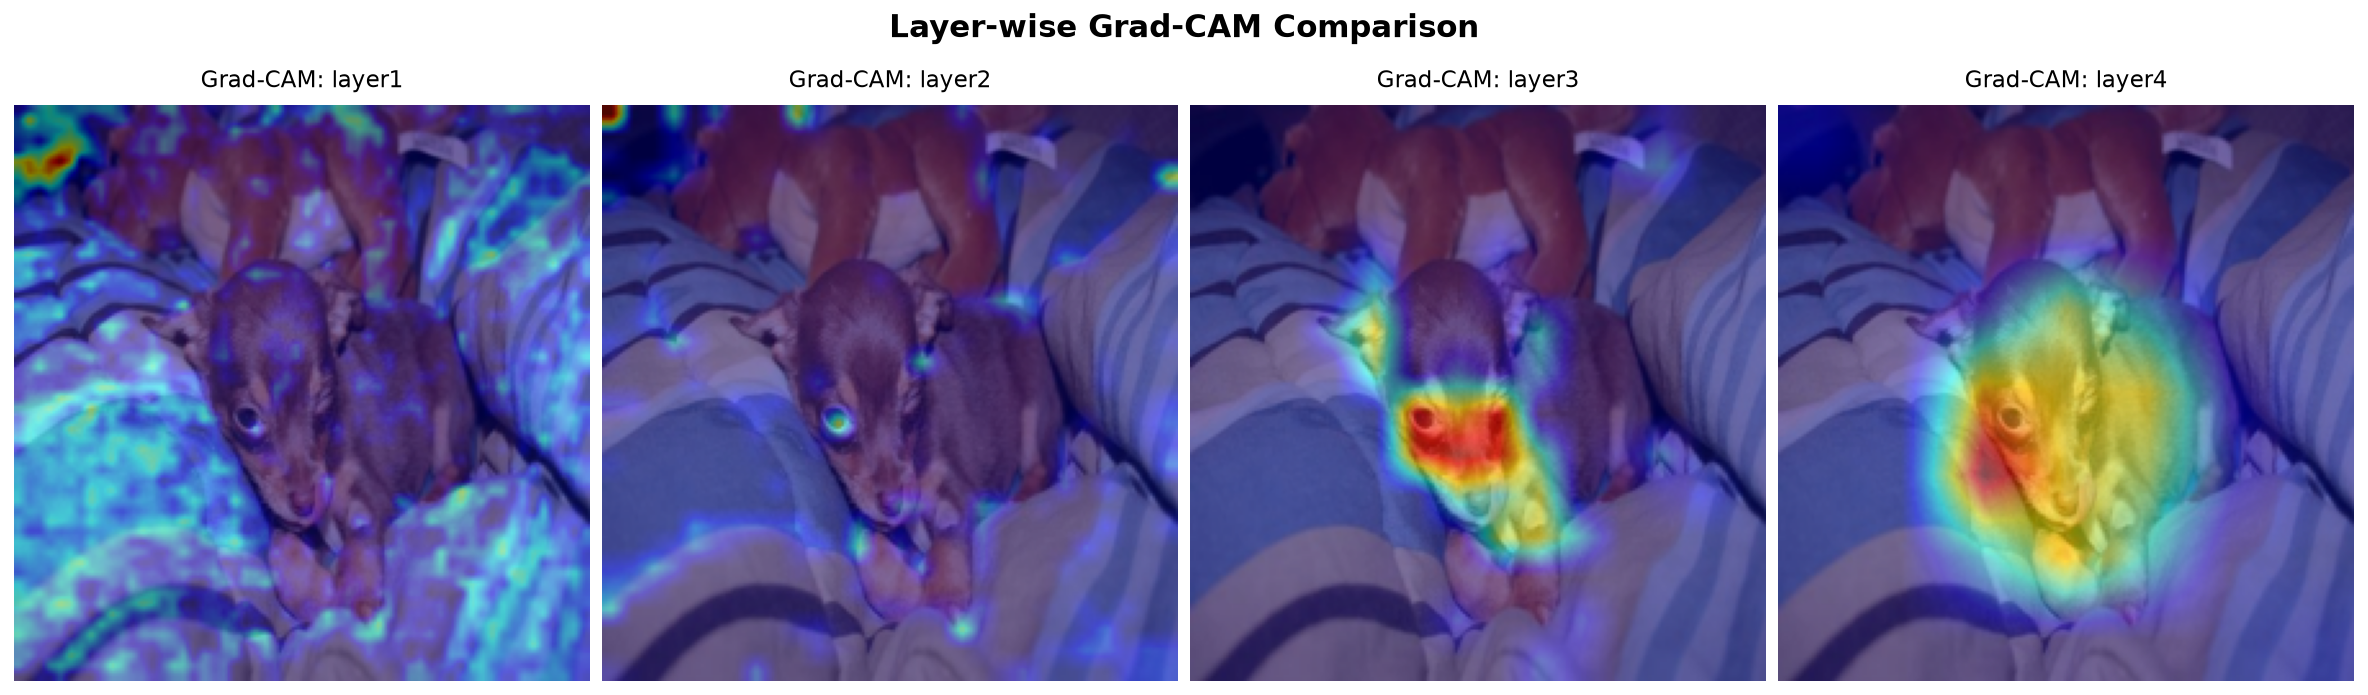

In [51]:
# 동일 이미지에 대해 얕은 layer1부터 깊은 layer4까지 Grad-CAM overlay를 한 figure에서 비교합니다.
# visualize_cam_on_image()는 독립 figure를 생성하는 함수이므로, subplot에서는 반환값을 직접 계산합니다.
original_image = unnormalize_image(_image_from_item(item))
layer_names = ("layer1", "layer2", "layer3", "layer4")

# 1행 4열 subplot을 먼저 만들고, 각 axis에 해당 layer의 overlay를 직접 지정합니다.
fig, axes = plt.subplots(1, len(layer_names), figsize=(16.8, 5.2), dpi=140, layout="constrained")
for axis, layer_name in zip(axes, layer_names, strict=True):
    # layer 이름을 전달하면 generate_grad_cam()이 model.named_modules()에서 실제 module을 찾습니다.
    grad_cam_image = generate_grad_cam(cam_model, layer_name, item)

    # 작은 activation map을 입력 이미지 크기로 resize한 뒤 RGB 원본에 alpha blending합니다.
    grad_cam_resized = cv2.resize(
        grad_cam_image,
        (original_image.shape[1], original_image.shape[0]),
        interpolation=cv2.INTER_LINEAR,
    )
    heatmap_bgr = cv2.applyColorMap(np.uint8(255 * grad_cam_resized), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(original_image, 0.5, heatmap_rgb, 0.5, 0)

    # 현재 subplot의 axis에 명시적으로 그리므로 빈 <Figure ... with 0 Axes>가 생기지 않습니다.
    axis.imshow(overlay)
    axis.set_title(f"Grad-CAM: {layer_name}", fontsize=12, pad=9)
    axis.axis("off")

fig.suptitle("Layer-wise Grad-CAM Comparison", fontsize=16, fontweight="bold")
plt.show()


##### 바운딩 박스 구하기

1. 제시된 코드를 참고해, 직접 Grad-CAM으로 얻은 CAM을 통해서 바운딩 박스를 얻어보세요.
2. 1)에서 얻은 바운딩 박스를 시각화해 보세요.

In [52]:
# heatmap thresholding → connected components → 최대 활성 영역 선택 → GT/예측 bbox 표시


def get_bbox(cam, threshold=0.5):
    """정규화 heatmap에서 가장 큰 연결 활성 영역의 (xmin, ymin, xmax, ymax)를 반환한다."""
    # threshold가 낮으면 넓은 영역, 높으면 강하게 활성화된 작은 영역을 얻습니다.
    if not 0 < threshold < 1:
        raise ValueError("threshold는 0과 1 사이여야 합니다.")

    # [0, 1] heatmap을 foreground(1)와 background(0) 이진 마스크로 바꿉니다.
    binary = (cam >= threshold).astype(np.uint8)
    # label 0은 background이며, stats에는 x, y, width, height, area가 저장됩니다.
    count, _, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if count <= 1:  # background 외에 활성화 영역이 없는 경우입니다.
        return None

    # 작은 노이즈보다 객체 후보가 될 가능성이 큰 최대 연결 요소를 선택합니다.
    index = int(np.argmax(stats[1:, cv2.CC_STAT_AREA])) + 1
    x, y, width, height, _ = stats[index]
    return int(x), int(y), int(x + width - 1), int(y + height - 1)


def visualize_bbox_on_image(img, pred_bbox, gt_bbox=None):
    """초록색 ground truth와 빨간색 예측 bbox를 원본 RGB 이미지에 그린다."""
    canvas = img.copy()  # 원본 배열은 보존하여 CAM·Grad-CAM 비교에 재사용합니다.
    if gt_bbox is not None:
        x1, y1, x2, y2 = map(lambda value: int(round(value)), gt_bbox)
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
    if pred_bbox is not None:
        x1, y1, x2, y2 = pred_bbox
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
    return canvas


##### IoU 구하기

1. 정답 바운딩 박스(ground truth) 와 예측값 바운딩 박스(prediction box) 두 가지를 이용해서 IoU를 계산하는 get_iou() 함수를 만들어 주세요.

In [53]:
# 교집합 면적 계산 → 합집합 면적 계산 → IoU = intersection / union


def get_iou(gt_bbox, pred_bbox):
    """ground truth와 prediction bbox의 IoU를 0~1 사이 값으로 계산한다."""
    # CAM threshold 결과가 없으면 예측 bbox가 없다고 보고 IoU를 0으로 정의합니다.
    if gt_bbox is None or pred_bbox is None:
        return 0.0

    gx1, gy1, gx2, gy2 = map(float, gt_bbox)
    px1, py1, px2, py2 = map(float, pred_bbox)

    # 교집합 좌상단은 각 좌상단의 max, 우하단은 각 우하단의 min입니다.
    ix1, iy1 = max(gx1, px1), max(gy1, py1)
    ix2, iy2 = min(gx2, px2), min(gy2, py2)
    intersection = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)

    # 교집합을 한 번만 빼야 합집합 면적이 됩니다.
    gt_area = max(0.0, gx2 - gx1) * max(0.0, gy2 - gy1)
    pred_area = max(0.0, px2 - px1) * max(0.0, py2 - py1)
    union = gt_area + pred_area - intersection
    return 0.0 if union <= 0 else intersection / union


1. CAM과 Grad-CAM으로 얻은 바운딩 박스와 정답 바운딩 박스와의 IoU를 각각 비교해 봅시다.

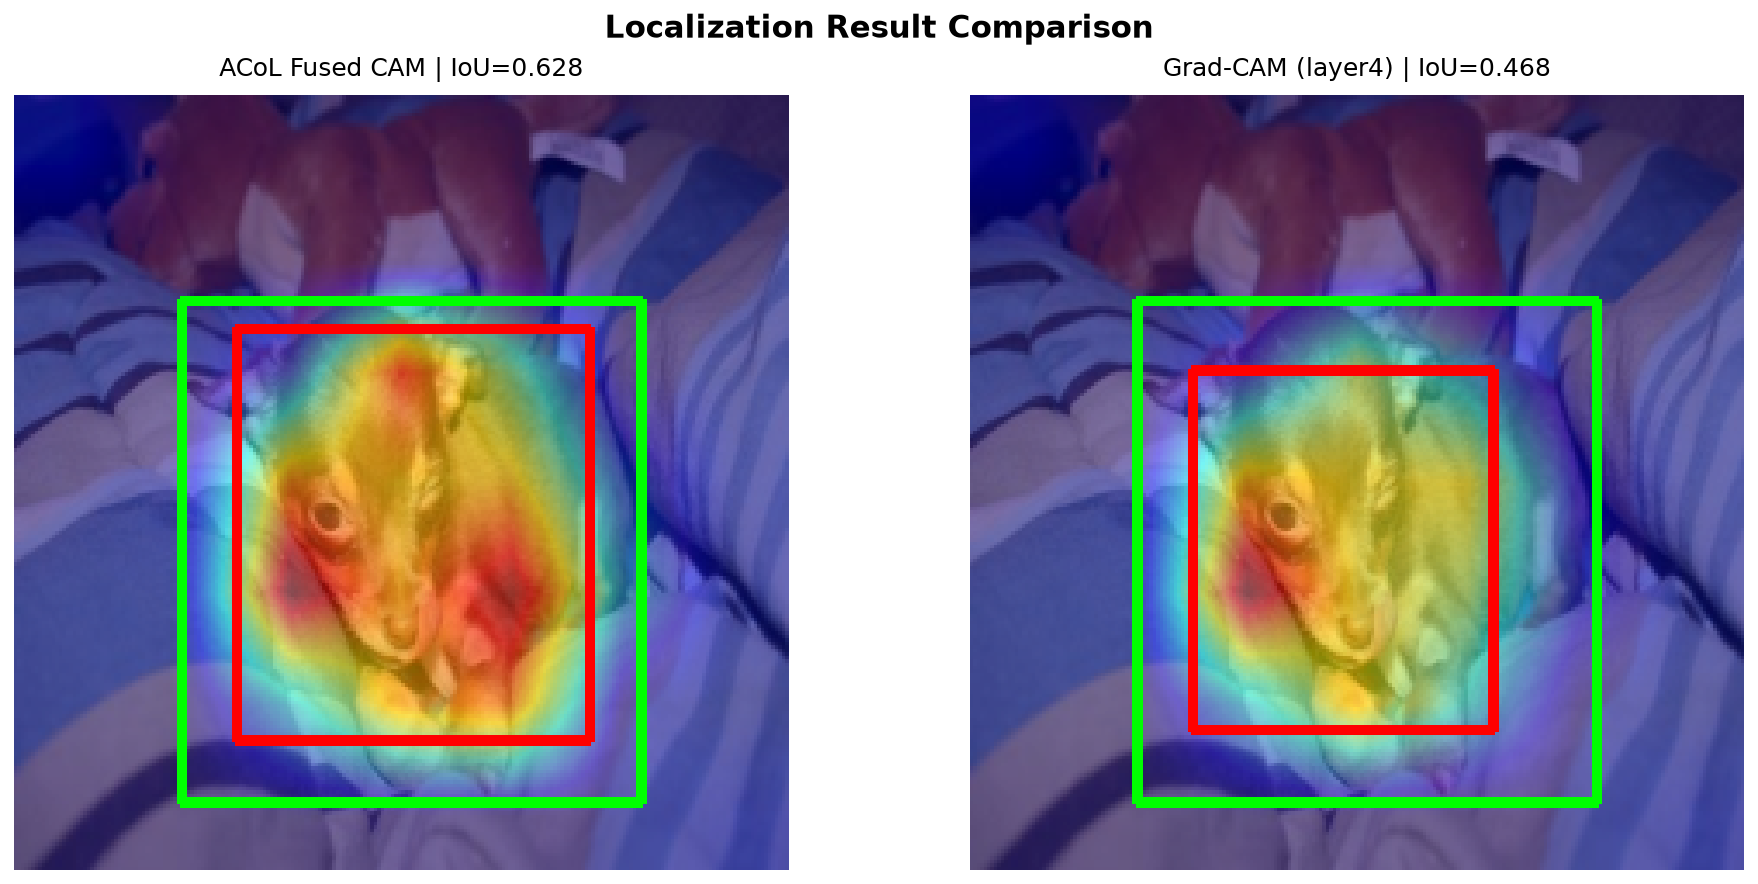

{'model_variant': 'acol', 'cam_iou': 0.627848856217733, 'grad_cam_iou': 0.4680158552527639}


In [54]:
# 동일 입력·동일 threshold로 ACoL fused CAM(또는 일반 CAM)과 Grad-CAM의 bbox 및 IoU를 비교합니다.
input_image = _image_from_item(item)
original_image = unnormalize_image(input_image)
gt_bbox = item.get("ground_bbox") if isinstance(item, dict) else None

# 1) 모델 variant에 맞는 CAM을 생성합니다. ACoL일 때는 두 branch의 fused map을 사용합니다.
if MODEL_VARIANT == "acol":
    acol_result = generate_acol_cam(cam_model, input_image)
    cam_image = acol_result.fused_cam.numpy()
    cam_title = "ACoL Fused CAM"
else:
    cam_image = generate_cam(cam_model, item)
    cam_title = "ResNet CAM"

# 2) Grad-CAM은 두 branch 평균 logit에 대한 layer4 gradient를 사용합니다.
grad_cam_image = generate_grad_cam(cam_model, cam_model.layer4, item)
# 중간 overlay는 출력하지 않고 최종 2열 비교 figure에서만 표시합니다.
cam_resized, cam_overlay = visualize_cam_on_image(
    cam_image, original_image, show=False
)
grad_resized, grad_overlay = visualize_cam_on_image(
    grad_cam_image, original_image, show=False
)

# 3) 같은 threshold=0.5로 bbox와 IoU를 계산합니다.
cam_bbox = get_bbox(cam_resized, threshold=0.5)
grad_bbox = get_bbox(grad_resized, threshold=0.5)
cam_iou = get_iou(gt_bbox, cam_bbox)
grad_iou = get_iou(gt_bbox, grad_bbox)

# 4) 초록색=정답, 빨간색=예측 bbox입니다.
fig, axes = plt.subplots(1, 2, figsize=(13.6, 6.2), dpi=140, layout="constrained")
axes[0].imshow(visualize_bbox_on_image(cam_overlay, cam_bbox, gt_bbox))
axes[0].set_title(f"{cam_title} | IoU={cam_iou:.3f}", fontsize=13, pad=10)
axes[1].imshow(visualize_bbox_on_image(grad_overlay, grad_bbox, gt_bbox))
axes[1].set_title(f"Grad-CAM (layer4) | IoU={grad_iou:.3f}", fontsize=13, pad=10)
for axis in axes:
    axis.axis("off")
fig.suptitle("Localization Result Comparison", fontsize=16, fontweight="bold")
plt.show()

print({"model_variant": MODEL_VARIANT, "cam_iou": cam_iou, "grad_cam_iou": grad_iou})
